In [ ]:
# 🌍 Deepfake Voice Detection – Cross Dataset (PA → Custom)

This notebook evaluates the model trained on the ASVspoof2019 Physical Access (PA) dataset on a custom dataset.

The goal is to analyze performance under **real-world domain shift conditions**.

In [ ]:
## 📌 Motivation

The PA dataset already includes real-world distortions such as:
- Noise
- Reverberation
- Replay artifacts

This experiment investigates whether training on more realistic data improves generalization to unseen datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get update -y
!apt-get install -y libsndfile1
!pip install soundfile librosa tqdm --quiet

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,935 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,879 kB]
Fetched 12.8 MB in 3s (3,946 kB/s)
Reading package lists... Don

In [ ]:
## 📦 1. Import Libraries

Libraries for:
- Audio processing (Librosa)
- Deep learning (PyTorch)
- Data handling (NumPy)
- Evaluation

In [ ]:
import os
import numpy as np
import soundfile as sf
import librosa
from tqdm import tqdm
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import torch
from torch.utils.data import Dataset
import random


In [ ]:
## 📂 2. Dataset Preparation

### Training Dataset
- ASVspoof2019 PA dataset
- Real-world replay attacks with noise

### Test Dataset
- Custom dataset (Turkish)
- Real + AI-generated speech

This setup evaluates cross-dataset performance under more realistic training conditions.

In [ ]:
if not os.path.exists("/content/PA"):
    !cp /content/drive/MyDrive/PA.zip /content/
    !unzip -q /content/PA.zip -d /content/

In [ ]:
def load_pa(audio_dir, protocol):

    files, labels = [], []

    with open(protocol) as f:
        for line in f:
            p = line.split()

            path = os.path.join(audio_dir, p[1] + ".flac")

            if os.path.exists(path):
                files.append(path)
                labels.append(0 if p[-1]=="bonafide" else 1)

    return files, labels

In [ ]:
pa_train_files, pa_train_labels = load_pa(
"/content/PA/ASVspoof2019_PA_train/flac",
"/content/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt"
)

pa_dev_files, pa_dev_labels = load_pa(
"/content/PA/ASVspoof2019_PA_dev/flac",
"/content/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.dev.trl.txt"
)

In [ ]:
pa_train_files = pa_train_files[:15000]
pa_train_labels = pa_train_labels[:15000]

In [ ]:
## 🔊 3. Feature Extraction (Log-Mel Spectrogram)

All audio samples are converted into log-Mel spectrograms:

- Sampling rate: 16 kHz
- 80 Mel bands
- FFT size: 1024
- Hop length: 256

Consistent preprocessing ensures fair comparison.

In [ ]:
def extract_logmel(path):

    try:
        audio, sr = sf.read(path)

        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)

    except:
        return None

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=80,
        n_fft=512,
        hop_length=160
    )

    logmel = librosa.power_to_db(mel)

    # delta
    delta = librosa.feature.delta(logmel)
    delta2 = librosa.feature.delta(logmel, order=2)

    feat = np.stack([logmel, delta, delta2], axis=0)

    feat = feat[:, :, :400]

    if feat.shape[2] < 400:
        feat = np.pad(feat, ((0,0),(0,0),(0,400-feat.shape[2])))

    return feat

In [ ]:
def build_cache(files, labels, folder):

    os.makedirs(folder, exist_ok=True)

    valid_labels = []
    idx = 0

    for i, path in tqdm(enumerate(files), total=len(files)):

        feat = extract_logmel(path)

        if feat is None:
            continue

        np.save(f"{folder}/{idx}.npy", feat)
        valid_labels.append(labels[i])

        idx += 1

    np.save(f"{folder}/labels.npy", valid_labels)

    print("Saved:", idx)

In [ ]:
build_cache(pa_train_files, pa_train_labels, "/content/pa_train_cache")

100%|██████████| 15000/15000 [02:47<00:00, 89.61it/s] 

Saved: 8048


In [ ]:
build_cache(pa_dev_files, pa_dev_labels, "/content/pa_dev_cache")

100%|██████████| 29700/29700 [05:35<00:00, 88.47it/s]

Saved: 15434


In [ ]:
def load_custom(root):

    files, labels = [], []

    for f in os.listdir(root+"/real"):
        files.append(root+"/real/"+f)
        labels.append(0)

    for f in os.listdir(root+"/fake"):
        files.append(root+"/fake/"+f)
        labels.append(1)

    return files, labels

In [ ]:
custom_files, custom_labels = load_custom(
"/content/drive/MyDrive/custom dataset"
)

build_cache(custom_files, custom_labels, "/content/custom_cache")

100%|██████████| 315/315 [00:06<00:00, 47.02it/s]

Saved: 162


In [ ]:
labels = np.load("/content/pa_train_cache/labels.npy")


labels = labels[:8048]

np.save("/content/pa_train_cache/labels.npy", labels)

print("Fixed:", len(labels))

Fixed: 8048


In [ ]:
len(np.load("/content/pa_train_cache/labels.npy"))

8048

In [ ]:
## 🔄 4. Data Augmentation

SpecAugment is applied during training:
- Time masking
- Frequency masking

This improves robustness to variations in audio.

In [ ]:
class FastDataset(Dataset):

    def __init__(self, folder, augment=False):

        self.folder = folder
        self.labels = np.load(folder + "/labels.npy")
        self.files = [f"{i}.npy" for i in range(len(self.labels))]
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        x = np.load(self.folder + "/" + self.files[idx])

        # normalization
        x = (x - np.mean(x)) / (np.std(x) + 1e-6)

        # AUGMENTATION
        if self.augment:

            # 1️. Gaussian noise
            if random.random() < 0.5:
                noise = np.random.normal(0, 0.01, x.shape)
                x = x + noise

            # 2. Time masking
            if random.random() < 0.3:
                t = random.randint(10, 50)
                x[:, :t] = 0

            # 3. Frequency masking
            if random.random() < 0.3:
                f = random.randint(5, 20)
                x[:f, :] = 0

        x = torch.tensor(x).float()
        y = torch.tensor(self.labels[idx]).long()

        return x, y

In [ ]:
train_ds = FastDataset("/content/pa_train_cache", augment=True)
dev_ds   = FastDataset("/content/pa_dev_cache")

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=64)

In [ ]:
import torch.nn as nn

class MFM(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels*2, kernel_size, stride, padding)

    def forward(self, x):
        x = self.conv(x)
        out = torch.split(x, x.shape[1]//2, dim=1)
        return torch.max(out[0], out[1])

In [ ]:
## 🧠 5. Model (LCNN)

The LCNN model is trained on the PA dataset and evaluated on the custom dataset without retraining.

This tests real-world generalization capability.

In [ ]:
import torch.nn.functional as F

class LCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = MFM(3, 32, 3)
        self.pool1 = nn.MaxPool2d(2)

        self.layer2 = MFM(32, 64, 3)
        self.pool2 = nn.MaxPool2d(2)

        self.layer3 = MFM(64, 128, 3)
        self.pool3 = nn.MaxPool2d(2)

        self.layer4 = MFM(128, 128, 3)
        self.pool4 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(128*5*25, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):



        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.pool4(self.layer4(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
## ⚙️ 6. Evaluation Setup

- Train on PA dataset
- Test on custom dataset

This represents a challenging domain shift:
- Different dataset distributions
- Different recording conditions
- Different languages

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LCNN().to(device)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 3.5]).to(device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

In [ ]:
def eval_model(model, loader):

    model.eval()

    scores, labels = [], []

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)

            p = torch.softmax(model(x),1)[:,1]

            scores.extend(p.cpu().numpy())
            labels.extend(y.numpy())

    fpr,tpr,_ = roc_curve(labels,scores)
    fnr = 1-tpr

    eer = fpr[np.argmin(np.abs(fnr-fpr))]

    return eer

In [ ]:
for epoch in range(6):

    model.train()

    for x,y in train_loader:

        x=x.to(device)
        y=y.to(device)

        optimizer.zero_grad()

        loss = criterion(model(x),y)

        loss.backward()
        optimizer.step()

    scheduler.step()

    eer = eval_model(model, dev_loader)

    print(f"Epoch {epoch} → EER: {eer:.4f}")

Epoch 0 → EER: 0.2802
Epoch 1 → EER: 0.2401
Epoch 2 → EER: 0.2084
Epoch 3 → EER: 0.1970
Epoch 4 → EER: 0.1852
Epoch 5 → EER: 0.1876


In [ ]:
custom_ds = FastDataset("/content/custom_cache", augment=True)
custom_loader = DataLoader(custom_ds, batch_size=32, shuffle=True)

In [ ]:
torch.save(model.state_dict(), "/content/best_model.pt")

In [ ]:
eer = eval_model(model, dev_loader)
print("Final EER:", eer)

Final EER: 0.1876359117738428


In [ ]:
def plot_roc(model, loader):

    model.eval()

    scores, labels = [], []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)

            probs = torch.softmax(model(x), 1)[:,1]

            scores.extend(probs.cpu().numpy())
            labels.extend(y.numpy())

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
def plot_det(model, loader):

    model.eval()

    scores, labels = [], []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)

            probs = torch.softmax(model(x), 1)[:,1]

            scores.extend(probs.cpu().numpy())
            labels.extend(y.numpy())

    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1 - tpr

    plt.figure()
    plt.plot(fpr, fnr)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("False Negative Rate (FNR)")
    plt.title("DET Curve")
    plt.grid()
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(model, loader):

    model.eval()

    preds, labels = [], []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)

            outputs = model(x)
            p = torch.argmax(outputs, dim=1)

            preds.extend(p.cpu().numpy())
            labels.extend(y.numpy())

    cm = confusion_matrix(labels, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Real","Fake"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

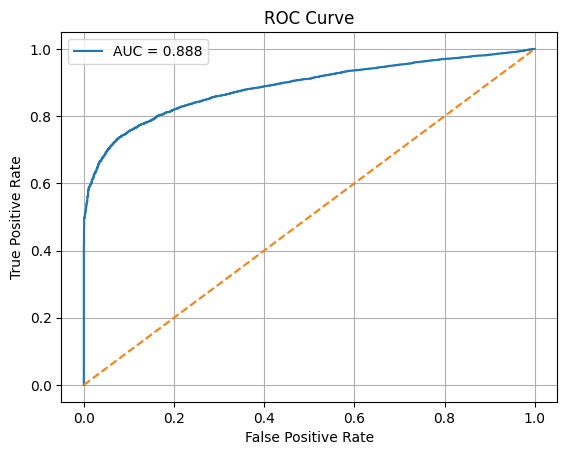

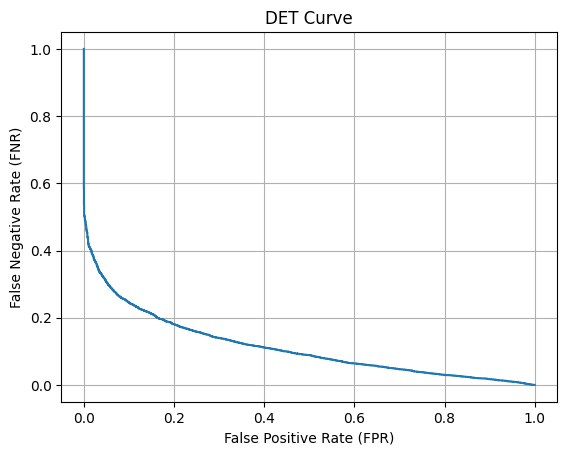

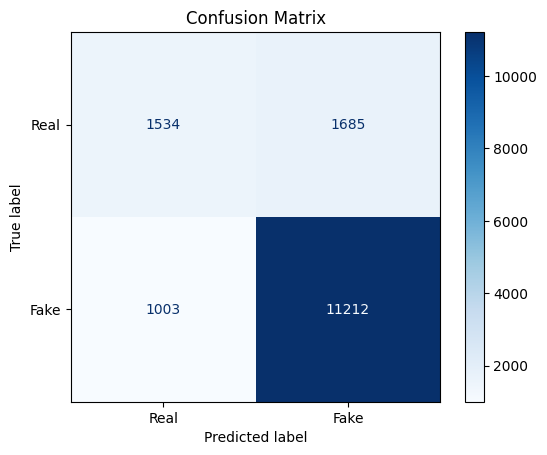

In [ ]:
plot_roc(model, dev_loader)
plot_det(model, dev_loader)
plot_confusion(model, dev_loader)

In [ ]:
torch.save(model.state_dict(), "final_model.pt")

In [ ]:
## 📊 7. Results

- EER (PA → Custom): **18.76%**
- AUC: **0.888**

The model shows a significant performance drop compared to in-domain evaluation.

In [ ]:
## 🔍 8. Analysis

Despite being trained on a more realistic dataset (PA), the model still struggles to generalize.

Reasons:
- Language mismatch (English vs Turkish)
- Different recording environments
- Limited diversity in training data
- Dataset-specific feature learning

The model misclassifies many real samples, indicating difficulty in distinguishing bonafide speech.

In [ ]:
## ⚠️ 9. Key Insight

Training on more realistic data does not fully solve the generalization problem.

Domain mismatch remains a major challenge in deepfake detection systems.

In [ ]:
## 🧾 10. Conclusion

This experiment demonstrates that even with realistic training data, cross-dataset performance remains limited.

Improving generalization requires:
- Diverse datasets
- Domain adaptation techniques
- Robust feature representations